# Sampling from Manifolds using Normalizing Flows

In [16]:
import numpy as np
from scipy.stats import norm, uniform
from abc import ABC, abstractmethod
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.distributions import Uniform

In [17]:
class NormalizingFlow(nn.Module):
  def __init__(self, neta, netb, mask):
    super().__init__()
    self.mask = nn.Parameter(mask, requires_grad=False)
    self.a = nn.ModuleList([neta() for _ in range(len(mask))])
    self.b = nn.ModuleList([netb() for _ in range(len(mask))])

  def T(self, z):
    log_det_j, x = z.new_zeros(z.shape[0]), z
    for neta, netb, m in zip(self.a, self.b, self.mask):
      y1, y2 = x * m, x * (1 - m)
      a = (1-m) * neta(y1)
      b = (1-m) * netb(y1)
      x = y1 + (y2 * torch.exp(b) + a)
      log_det_j += torch.sum(b, dim=1)
    return x, log_det_j

  def Tinv(self, x):
    log_det_j, z = x.new_zeros(x.shape[0]), x
    for neta, netb, m in reversed(list(zip(self.a, self.b, self.mask))):
      w1, w2 = z * m, z * (1 - m)
      a = (1-m) * neta(w1)
      b = (1-m) * netb(w1)
      z = w1 + (w2 - a) * torch.exp(-b)
      log_det_j -= torch.sum(b, dim=1)
    return z, log_det_j

def make_default_flow(dim, n_layers=6, hidden_dim=256):
    def make_neta():
        return lambda: nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.LeakyReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(),
            nn.Linear(hidden_dim, dim)
        )

    def make_netb():
        return lambda: nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.LeakyReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(),
            nn.Linear(hidden_dim, dim),
            nn.Tanh()
        )

    masks = torch.tensor([[(i + j) % 2 for j in range(dim)] for i in range(n_layers)], dtype=torch.float32)
    return NormalizingFlow(make_neta(), make_netb(), masks)

In [49]:
def uniform(bounds):
  lows, highs = zip(*bounds)
  return Uniform(torch.tensor(lows, dtype=torch.float32), torch.tensor(highs, dtype=torch.float32))

def train_flow(nflow, log_density, ref, batch_size=64, nsteps=100, lr=1e-4, clip_value=1.0):
  optim = torch.optim.Adam(nflow.parameters(), lr=lr)
  kls = []
  for step in range(nsteps):
    z = ref.sample((batch_size,))
    x, log_det = nflow.T(z)
    kl = -torch.mean(log_det) - torch.mean(log_density(x))
    optim.zero_grad()
    kl.backward()
    torch.nn.utils.clip_grad_norm_(nflow.parameters(), max_norm=clip_value)
    optim.step()
    kls.append(kl)
  return kls

In [50]:
class RiemannianManifold(ABC):
    def __init__(self, bounds, dim, vf_bound, nflow=None, ref=None):
        self.bounds = bounds
        self.dim = dim
        self.vf_bound = vf_bound
        self.ref = ref or uniform(bounds)
        self.nflow = nflow or make_default_flow(dim)

    @abstractmethod
    def coords(self, u):
        pass

    def metric(self, u):
        pass

    def volume_form(self, u):
        return torch.sqrt(torch.linalg.det(self.metric(u)))

    def log_density(self, x):
        return torch.log(self.volume_form(x))

    def train(self, **kwargs):
        return train_flow(self.nflow, self.log_density, self.ref, **kwargs)

    def sample(self, n_samples):
        z = self.ref.sample((n_samples,))
        x, _ = self.nflow.T(z)
        return [self.coords(y) for y in x]

    def _param_samples(self, n_samples, M):
        samples = []

        while len(samples) < n_samples:
            x = uniform(self.bounds).sample()
            u = torch.rand(())

            if u * M <= self.volume_form(x):
                samples.append(x)

        return samples

    def old_sample(self, n_samples):
        param_samples = self._param_samples(n_samples, self.vf_bound)
        return [self.coords(x) for x in param_samples]

## Torus

In [51]:
class Torus(RiemannianManifold):
    def __init__(self, R, r):
        self.R = R
        self.r = r
        vf_bound = (R + r) * r
        super().__init__(
            bounds=[(0, 2 * torch.pi), (0, 2 * torch.pi)],
            dim=2,
            vf_bound=vf_bound,
        )

    def coords(self, u):
        theta, phi = u[..., 0], u[..., 1]

        x = (self.R + self.r * torch.cos(theta)) * torch.cos(phi)
        y = (self.R + self.r * torch.cos(theta)) * torch.sin(phi)
        z = self.r * torch.sin(theta)

        return torch.stack([x, y, z], dim=-1)

    def metric(self, u):
        theta = u[..., 0]

        g11 = (self.R + self.r * torch.cos(theta))**2
        g22 = self.r**2 * torch.ones_like(theta)

        return torch.diag_embed(torch.stack([g11, g22], dim=-1))

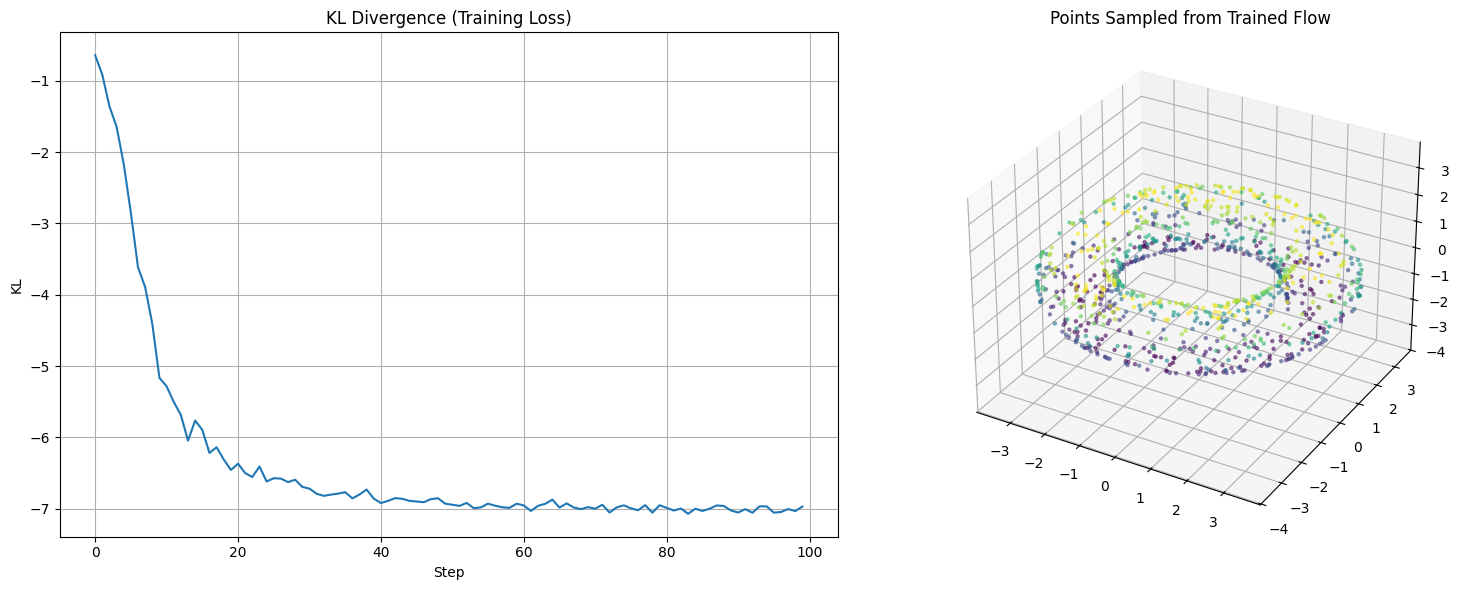

In [52]:
torus = Torus(R=3.0, r=1.0)

kl_history = torus.train()
points_flow = torch.stack(torus.sample(1000)).detach().numpy()
fig = plt.figure(figsize=(16, 6))

ax1 = fig.add_subplot(121)
ax1.plot([kl.item() for kl in kl_history])
ax1.set_title("KL Divergence (Training Loss)")
ax1.set_xlabel("Step")
ax1.set_ylabel("KL")
ax1.grid(True)

ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(points_flow[:, 0], points_flow[:, 1], points_flow[:, 2], s=5, alpha=0.5, c=points_flow[:, 2], cmap='viridis')
ax2.set_title("Points Sampled from Trained Flow")

max_range = np.array([points_flow[:,0].max()-points_flow[:,0].min(), points_flow[:,1].max()-points_flow[:,1].min(), points_flow[:,2].max()-points_flow[:,2].min()]).max() / 2.0
mid_x, mid_y, mid_z = points_flow.mean(axis=0)
ax2.set_xlim(mid_x - max_range, mid_x + max_range)
ax2.set_ylim(mid_y - max_range, mid_y + max_range)
ax2.set_zlim(mid_z - max_range, mid_z + max_range)

plt.tight_layout()
plt.show()